In [1]:
import sys
import os
import importlib
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import utils.color_utils as color_utils
importlib.reload(color_utils)
ColorLibrary = color_utils.ColorLibrary

cl = ColorLibrary.from_categorized_csv('../datasets/categorized_colors.csv')
print(f"Loaded {len(cl.categories)} categories:")
cl.summary()

Loaded 13 categories:
red: 20 colors
orange: 19 colors
yellow: 34 colors
green: 44 colors
blue: 31 colors
violet: 11 colors
purple: 25 colors
white: 6 colors
gray: 20 colors
black: 7 colors
pink: 25 colors
brown: 27 colors
olive: 17 colors


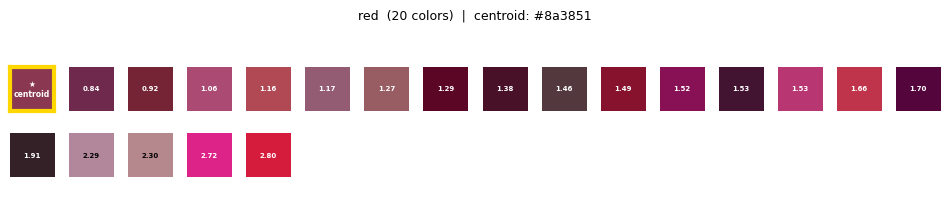

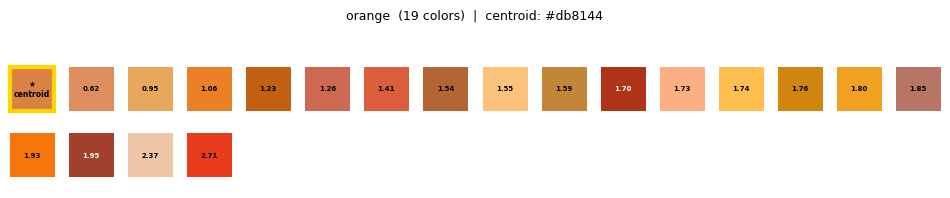

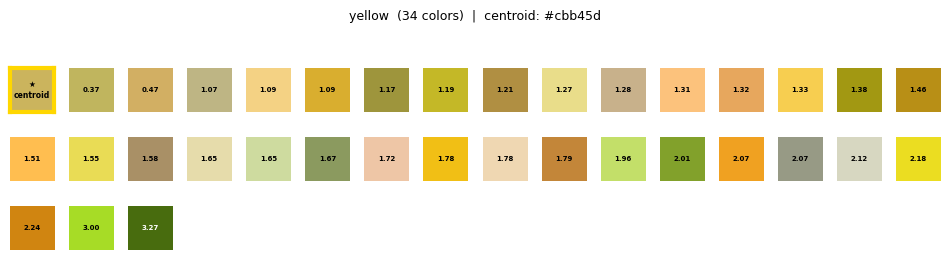

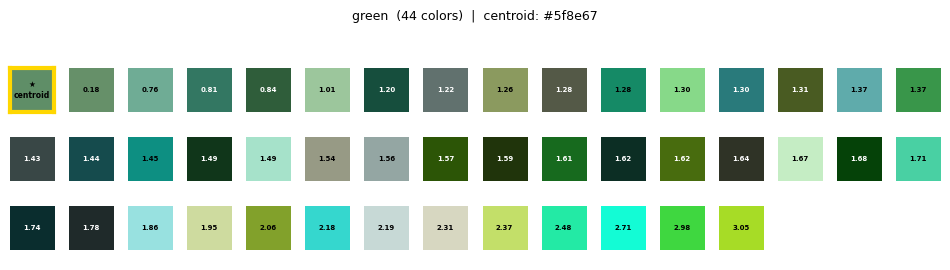

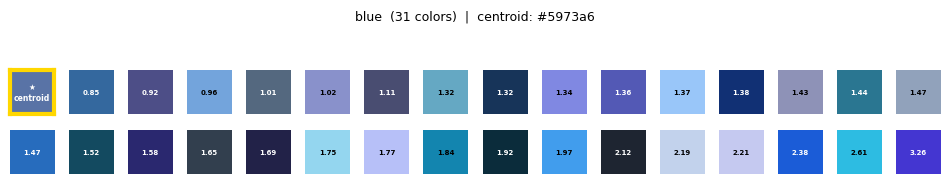

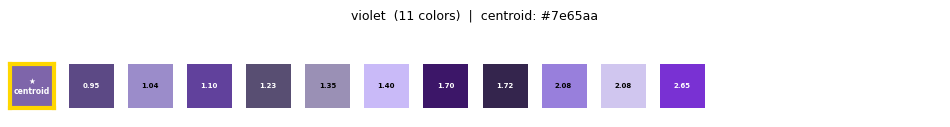

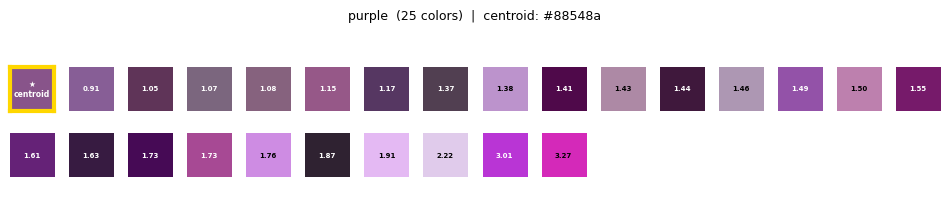

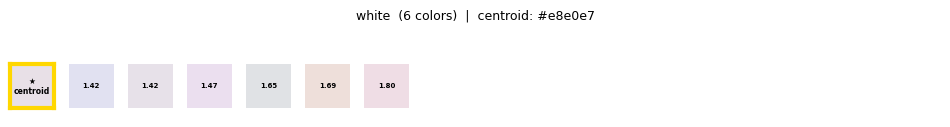

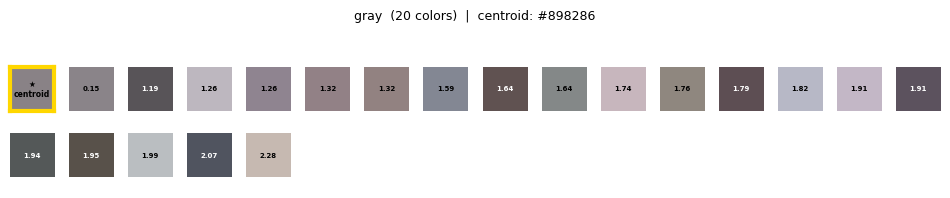

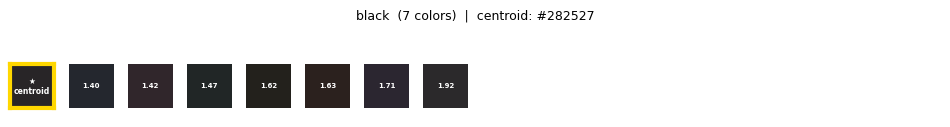

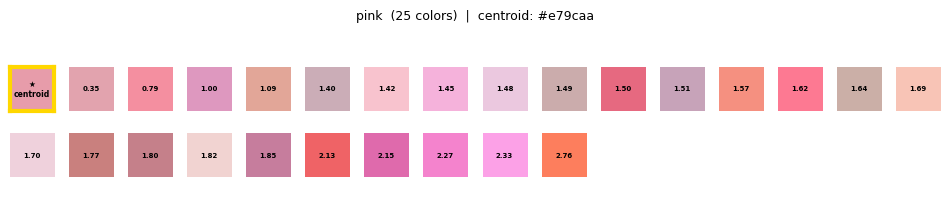

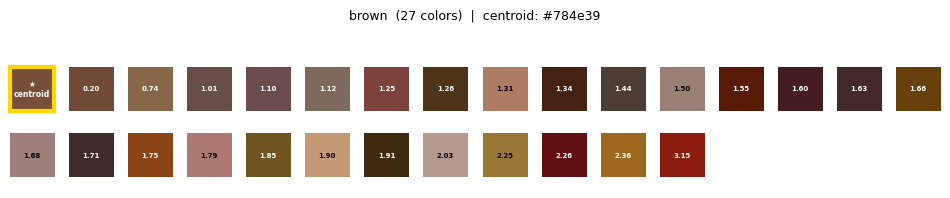

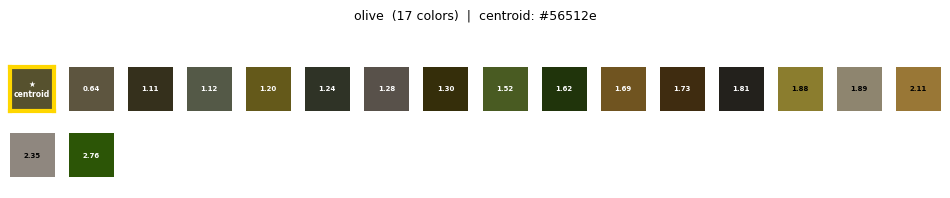

In [2]:
import math
import matplotlib.pyplot as plt

NCOLS = 16

for cat in cl.categories:
    sorted_colors = cl.get_category_mahalanobis_distances(cat)   # [(hex, dist), ...]
    centroid_lab  = cl.get_category_centroid(cat)
    _, centroid_hex = cl._lab_to_hex(*centroid_lab)

    n     = len(sorted_colors)
    total = n + 1                                                 # centroid occupies slot 0
    nrows = math.ceil(total / NCOLS)

    fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 0.6, nrows * 0.7 + 0.5))
    axes = axes.flatten() if nrows * NCOLS > 1 else [axes]

    # ── slot 0: centroid ─────────────────────────────────────────
    ax = axes[0]
    h   = centroid_hex.lstrip('#')
    rgb = [int(h[j:j+2], 16) / 255 for j in (0, 2, 4)]
    ax.imshow([[[*rgb]]])
    L_c = centroid_lab[0]
    txt_color = 'black' if L_c > 50 else 'white'
    ax.text(0.5, 0.5, '★\ncentroid', transform=ax.transAxes,
            ha='center', va='center', fontsize=5.5, color=txt_color, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor('gold'); spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

    # ── slots 1…n: colors sorted by Mahalanobis distance (near → far) ──
    for i, (hx, dist) in enumerate(sorted_colors):
        ax = axes[i + 1]
        h   = hx.lstrip('#')
        rgb = [int(h[j:j+2], 16) / 255 for j in (0, 2, 4)]
        ax.imshow([[[*rgb]]])
        L_val, _, _ = cl._hex_to_lab(hx)
        txt_color = 'black' if L_val > 50 else 'white'
        ax.text(0.5, 0.5, f'{dist:.2f}', transform=ax.transAxes,
                ha='center', va='center', fontsize=5, color=txt_color, fontweight='bold')
        ax.axis('off')

    # ── hide unused axes ─────────────────────────────────────────
    for j in range(n + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{cat}  ({n} colors)  |  centroid: {centroid_hex}', fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

palette  = cm.get_cmap('tab20', len(cl.categories))
handles  = []

for idx, cat in enumerate(cl.categories):
    color = palette(idx)
    points = np.array([cl._hex_to_lab(hx) for hx in cl.color_library[cat]])  # (n, 3) as L,a,b
    abc    = points[:, [1, 2, 0]]  # reorder to a*, b*, L* for the plot axes

    # scatter the raw points
    ax.scatter(*abc.T, color=color, s=6, alpha=0.4, depthshade=True)

    # convex hull (needs ≥ 4 non-coplanar points)
    if len(points) >= 4:
        try:
            hull = ConvexHull(abc)
            verts = [abc[s] for s in hull.simplices]
            poly  = Poly3DCollection(verts, alpha=0.10, facecolor=color, edgecolor=color, linewidth=0.3)
            ax.add_collection3d(poly)
        except Exception:
            pass  # degenerate hull — skip silently

    # centroid star
    L_c, a_c, b_c = cl.get_category_centroid(cat)
    ax.scatter([a_c], [b_c], [L_c], marker='*', s=80, color=color,
               edgecolors='black', linewidths=0.5, zorder=5, depthshade=False)

    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                               markersize=8, label=cat))

ax.set_xlabel('a* (green–red)')
ax.set_ylabel('b* (blue–yellow)')
ax.set_zlabel('L* (lightness)')
ax.set_xlim(-128, 128)
ax.set_ylim(-128, 128)
ax.set_zlim(0, 100)
ax.set_title('All categories — CIELAB convex hulls  (★ = centroid)')
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=7, framealpha=0.7)
plt.tight_layout()
plt.show()


## Distance from centroid in CIELAB — Mahalanobis distance

### Why CIELAB?
Each color is stored as a point $(L^*, a^*, b^*)$ in **CIELAB** (CIE 1976 $L^*a^*b^*$) space.
CIELAB is perceptually uniform: a Euclidean step of the same magnitude corresponds to roughly the same perceived color difference regardless of where in the space you are.
$L^*$ encodes lightness (0 = black, 100 = white), $a^*$ encodes green–red, and $b^*$ encodes blue–yellow.

### Why Mahalanobis over plain Euclidean ($\Delta E^*$)?
The color cloud for a category is rarely a sphere.
A *sky-blue* group might be tightly clustered in hue but spread across a wide lightness range; a *skin-tone* group might form a diagonal band in the $a^*$–$L^*$ plane.
Plain Euclidean distance ($\Delta E = \sqrt{\Delta L^{*2} + \Delta a^{*2} + \Delta b^{*2}}$) treats all axes equally and ignores these correlations, so a perfectly typical light-blue would look "far" from its centroid just because it happens to be bright.

**Mahalanobis distance** corrects for this by normalising with the category's own covariance matrix $S$:

$$d_M(\mathbf{x},\,\boldsymbol{\mu}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^\top \, S^{-1} \, (\mathbf{x} - \boldsymbol{\mu})}$$

where $\boldsymbol{\mu}$ is the per-category CIELAB centroid and $S$ is the $3\times3$ covariance matrix of all member colors.

$S^{-1}$ stretches/rotates the space so that the natural spread of the category becomes the unit sphere.
A distance of **1** means "one standard deviation away along the principal axis of that group", making distances **comparable across categories** and interpretable as a rough $z$-score.

### Practical note — singular covariance
If a category has fewer than 4 points (or all points are collinear/coplanar), $S$ is singular and cannot be inverted.
In this case `get_category_mahalanobis_distances` and `get_color_mahalanobis_distance` fall back to plain Euclidean distance and emit a console warning.

### API
| Method | Returns |
|---|---|
| `cl.get_category_mahalanobis_distances(cat)` | `[(hex, dist), ...]` sorted nearest → furthest |
| `cl.get_color_mahalanobis_distance(cat, L, a, b)` | distance of a single CIELAB point from the category |
| `cl.get_category_centroid(cat)` | `(L*, a*, b*)` arithmetic mean centroid |
